## Title
Seleccion mejor modelo
### By:
Dovaribi Carupia Yagari

### Date:
2026-08-21

### Description:

# Requerimiento

Realizar el proceso de selección del mejor modelo de machine learning para resolver el problema de machine learning. Este modelo debe ser mejor que el modelo baseline. En este notebook se elige la alternativa manual, sin utilizar AutoML.

> Tomar como ejemplo los pasos de: <https://joserzapata.github.io/post/ciencia-datos-proyecto-python/6-model_selection/>

El proceso manual incluye:

- Usar el pipeline de procesamiento de datos de la tarea anterior.
- Dividir los datos en Train / Test.
- Seleccionar múltiples modelos de machine learning, mínimo cuatro tipos diferentes.
- Evaluar con métricas apropiadas para clasificación médica.
- Eliminar modelos por debajo del promedio y conservar los mejores.
- Optimizar los dos o tres mejores modelos con validación cruzada y pipelines.
- Comparar los resultados con pruebas estadísticas y seleccionar el mejor modelo.
- Entrenar el modelo seleccionado con todo train y evaluar una sola vez en test.
- Analizar underfitting, overfitting, learning curve y escalabilidad.
- Almacenar el pipeline completo de preprocesamiento y modelo en formato `.joblib`.
- Interpretar resultados y definir recomendaciones.

# Entregables

Notebook con la selección manual, optimización, evaluación y almacenamiento del mejor pipeline. Se requiere revisión y validación del CI/CD antes del Pull Request.

## 📚 Import  libraries

## 1. Estrategia y prevención de data leakage

Se mantiene la secuencia de los notebooks 04 y 05. La limpieza determinista elimina target faltante y duplicados antes del split; todas las transformaciones que aprenden parámetros permanecen dentro del pipeline.

El conjunto `X_test` queda reservado hasta la evaluación final. La comparación inicial, la optimización y las pruebas estadísticas utilizan exclusivamente `X_train`. Para que el modelo guardado pueda reutilizarse en Streamlit, el pipeline compartido vive en `src/model/preprocessing.py` y no depende de clases definidas únicamente en el notebook.

## 2. Librerías, datos y split

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import dump
from scipy.stats import ttest_rel, wilcoxon
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model.preprocessing import build_feature_pipeline, load_supervised_data  # noqa: E402

In [ ]:
DATA_PATH = PROJECT_ROOT / "data" / "02_intermediate" / "pacientes_higado_exploracion.parquet"
TARGET_MAPPING = {1: 1, 2: 0}

X, y = load_supervised_data(DATA_PATH)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "Dataset": ["Train", "Test"],
        "Rows": [len(X_train), len(X_test)],
        "Disease_rate_%": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
    }
)
display(split_summary)
print("Las transformaciones todavía no se han ajustado.")

,Dataset,Rows,Disease_rate_%
0,Train,470,70.85
1,Test,118,71.19


Las transformaciones todavía no se han ajustado.


## 3. Catálogo manual de modelos

Se comparan cuatro familias distintas, todas dentro del mismo pipeline de transformación:

- Regresión logística: referencia lineal e interpretable.
- Árbol de decisión: reglas no lineales y fáciles de explicar.
- Random Forest: conjunto de árboles con menor varianza.
- SVC: modelo de margen capaz de representar fronteras no lineales.

El peso balanceado se activa en los modelos que lo soportan para que el baseline no se compare únicamente con accuracy.

In [ ]:
def build_model_pipeline(model) -> Pipeline:
    """Create a fresh feature-and-model pipeline."""
    return Pipeline(
        steps=[
            ("features", build_feature_pipeline()),
            ("model", model),
        ]
    )


model_catalog = {
    "logistic_regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42
    ),
    "decision_tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "random_forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "svc": SVC(class_weight="balanced", random_state=42),
}

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 4. Comparación inicial con validación cruzada

La validación inicial se ejecuta solo sobre train. Se conserva el `DummyClassifier` como referencia y se comparan los cuatro modelos reales con las mismas particiones.

In [ ]:
comparison_catalog = {
    "dummy_baseline": DummyClassifier(strategy="most_frequent"),
    **model_catalog,
}
comparison_rows = []

for model_name, model in comparison_catalog.items():
    pipeline = build_model_pipeline(clone(model))
    results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
    )
    comparison_rows.append(
        {
            "model": model_name,
            **{f"{metric}_mean": results[f"test_{metric}"].mean() for metric in scoring},
            **{f"{metric}_std": results[f"test_{metric}"].std() for metric in scoring},
            "fit_time_mean": results["fit_time"].mean(),
        }
    )

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        ["balanced_accuracy_mean", "recall_mean", "f1_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)
display(comparison.round(4))

,model,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,average_precision_mean,accuracy_std,balanced_accuracy_std,precision_std,recall_std,f1_std,roc_auc_std,average_precision_std,fit_time_mean
0,svc,0.6532,0.7036,0.8898,0.5826,0.7038,0.7478,0.8887,0.0248,0.0235,0.0173,0.0290,0.0247,0.0310,0.0179,0.1030
1,logistic_regression,0.6660,0.6953,0.8683,0.6247,0.7256,0.7358,0.8825,0.0334,0.0408,0.0352,0.0399,0.0294,0.0373,0.0273,0.1847
2,random_forest,0.6936,0.6548,0.8077,0.7477,0.7751,0.7263,0.8763,0.0170,0.0289,0.0250,0.0461,0.0186,0.0165,0.0154,0.4392
3,decision_tree,0.6319,0.5508,0.7381,0.7448,0.7401,0.5508,0.7314,0.0488,0.0510,0.0265,0.0680,0.0422,0.0510,0.0202,0.1333
4,dummy_baseline,0.7085,0.5000,0.7085,1.0000,0.8294,0.5000,0.7085,0.0052,0.0000,0.0052,0.0000,0.0036,0.0000,0.0052,0.1841


In [ ]:
real_model_comparison = comparison[comparison["model"] != "dummy_baseline"].copy()
average_balanced_accuracy = real_model_comparison["balanced_accuracy_mean"].mean()
above_average = real_model_comparison[
    real_model_comparison["balanced_accuracy_mean"] >= average_balanced_accuracy
]
top_model_names = (
    above_average.sort_values(
        ["balanced_accuracy_mean", "recall_mean", "f1_mean"],
        ascending=False,
    )
    .head(3)["model"]
    .tolist()
)

print(f"Promedio de balanced accuracy de modelos reales: {average_balanced_accuracy:.4f}")
print(f"Modelos conservados para optimización: {top_model_names}")
display(above_average.round(4))

Promedio de balanced accuracy de modelos reales: 0.6511
Modelos conservados para optimización: ['svc', 'logistic_regression', 'random_forest']


,model,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean,average_precision_mean,accuracy_std,balanced_accuracy_std,precision_std,recall_std,f1_std,roc_auc_std,average_precision_std,fit_time_mean
0,svc,0.6532,0.7036,0.8898,0.5826,0.7038,0.7478,0.8887,0.0248,0.0235,0.0173,0.0290,0.0247,0.0310,0.0179,0.1030
1,logistic_regression,0.6660,0.6953,0.8683,0.6247,0.7256,0.7358,0.8825,0.0334,0.0408,0.0352,0.0399,0.0294,0.0373,0.0273,0.1847
2,random_forest,0.6936,0.6548,0.8077,0.7477,0.7751,0.7263,0.8763,0.0170,0.0289,0.0250,0.0461,0.0186,0.0165,0.0154,0.4392


## 5. Optimización manual de hiperparámetros

Los grids se definen manualmente y `GridSearchCV` solo automatiza la evaluación de las combinaciones. La métrica de refit es `balanced_accuracy`, mientras que Recall, F1 y ROC-AUC se conservan para el análisis médico.

In [ ]:
param_grids = {
    "logistic_regression": {
        "model__C": [0.01, 0.1, 1.0, 10.0],
        "model__class_weight": ["balanced", None],
        "model__solver": ["liblinear"],
    },
    "decision_tree": {
        "model__max_depth": [2, 3, 5, None],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": ["balanced", None],
    },
    "random_forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_leaf": [1, 5],
        "model__class_weight": ["balanced", None],
    },
    "svc": {
        "model__C": [0.1, 1.0, 10.0],
        "model__gamma": ["scale", "auto"],
        "model__class_weight": ["balanced", None],
    },
}

inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

## 6. Comparación anidada y pruebas estadísticas

Para evitar que la optimización contamine la comparación, cada modelo se optimiza con un CV interno y se evalúa en folds externos que no participaron en la selección de hiperparámetros. Las pruebas pareadas comparan los scores de los mismos folds externos; con solo cinco folds, los p-valores se interpretan como evidencia exploratoria.

In [ ]:
def positive_scores(estimator, features: pd.DataFrame) -> np.ndarray:
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(features)[:, 1]
    return estimator.decision_function(features)


def nested_model_scores(model_name: str) -> pd.DataFrame:
    outer_rows = []
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for fold, (outer_train, outer_validation) in enumerate(outer_cv.split(X_train, y_train), 1):
        search = GridSearchCV(
            build_model_pipeline(clone(model_catalog[model_name])),
            param_grids[model_name],
            scoring=scoring,
            refit="balanced_accuracy",
            cv=inner_cv,
            n_jobs=-1,
        )
        X_outer_train = X_train.iloc[outer_train]
        X_outer_validation = X_train.iloc[outer_validation]
        y_outer_train = y_train.iloc[outer_train]
        y_outer_validation = y_train.iloc[outer_validation]
        search.fit(X_outer_train, y_outer_train)

        predictions = search.predict(X_outer_validation)
        scores = positive_scores(search.best_estimator_, X_outer_validation)
        outer_rows.append(
            {
                "fold": fold,
                "balanced_accuracy": balanced_accuracy_score(y_outer_validation, predictions),
                "recall": recall_score(y_outer_validation, predictions, zero_division=0),
                "f1": f1_score(y_outer_validation, predictions, zero_division=0),
                "roc_auc": roc_auc_score(y_outer_validation, scores),
            }
        )

    return pd.DataFrame(outer_rows)


nested_scores = {model_name: nested_model_scores(model_name) for model_name in top_model_names}
nested_summary_rows = []
for model_name, scores in nested_scores.items():
    summary_row = {"model": model_name}
    for metric in ["balanced_accuracy", "recall", "f1", "roc_auc"]:
        summary_row[f"{metric}_mean"] = scores[metric].mean()
        summary_row[f"{metric}_std"] = scores[metric].std()
    nested_summary_rows.append(summary_row)

nested_summary = pd.DataFrame(nested_summary_rows).sort_values(
    "balanced_accuracy_mean", ascending=False
)
display(nested_summary.round(4))

,model,balanced_accuracy_mean,balanced_accuracy_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
1,logistic_regression,0.7076,0.0532,0.6128,0.0563,0.7227,0.0437,0.7312,0.0415
0,svc,0.6972,0.0294,0.5408,0.0566,0.6742,0.0423,0.7389,0.0326
2,random_forest,0.6659,0.0294,0.6157,0.0893,0.7078,0.0463,0.7073,0.0252


In [ ]:
selected_model_name = nested_summary.iloc[0]["model"]
reference_scores = nested_scores[selected_model_name]["balanced_accuracy"]
statistical_rows = []

for model_name, scores in nested_scores.items():
    if model_name == selected_model_name:
        continue
    model_scores = scores["balanced_accuracy"]
    paired_ttest = ttest_rel(reference_scores, model_scores)
    try:
        paired_wilcoxon = wilcoxon(reference_scores, model_scores)
        wilcoxon_pvalue = paired_wilcoxon.pvalue
    except ValueError:
        wilcoxon_pvalue = np.nan
    statistical_rows.append(
        {
            "reference_model": selected_model_name,
            "compared_model": model_name,
            "mean_difference": (reference_scores - model_scores).mean(),
            "paired_t_pvalue": paired_ttest.pvalue,
            "wilcoxon_pvalue": wilcoxon_pvalue,
        }
    )

statistical_comparison = pd.DataFrame(statistical_rows)
display(statistical_comparison.round(4))
print("Las pruebas estadísticas son exploratorias por el tamaño de la muestra de folds.")

,reference_model,compared_model,mean_difference,paired_t_pvalue,wilcoxon_pvalue
0,logistic_regression,svc,0.0104,0.4902,0.4375
1,logistic_regression,random_forest,0.0417,0.2517,0.3125


Las pruebas estadísticas son exploratorias por el tamaño de la muestra de folds.


## 7. Ajuste final y evaluación en test

Después de seleccionar el modelo con la comparación anidada, se realiza una última búsqueda de hiperparámetros usando todo `X_train`. Solo después se evalúa el pipeline final en `X_test`.

In [ ]:
final_search = GridSearchCV(
    build_model_pipeline(clone(model_catalog[selected_model_name])),
    param_grids[selected_model_name],
    scoring=scoring,
    refit="balanced_accuracy",
    cv=inner_cv,
    return_train_score=True,
    n_jobs=-1,
)
final_search.fit(X_train, y_train)
best_pipeline = final_search.best_estimator_

print(f"Modelo seleccionado: {selected_model_name}")
print(f"Mejores hiperparámetros: {final_search.best_params_}")
print(f"Mejor balanced accuracy de CV interna: {final_search.best_score_:.4f}")

Modelo seleccionado: logistic_regression
Mejores hiperparámetros: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}
Mejor balanced accuracy de CV interna: 0.7027


,train,test
accuracy,0.6723,0.6864
balanced_accuracy,0.7108,0.7360
precision_disease,0.8841,0.9123
recall_disease,0.6186,0.6190
f1_disease,0.7279,0.7376
roc_auc,0.7443,0.8148
average_precision,0.8835,0.9160
specificity,0.8029,0.8529


Reporte de clasificación en test:
                precision    recall  f1-score   support

Sin enfermedad       0.48      0.85      0.61        34
    Enfermedad       0.91      0.62      0.74        84

      accuracy                           0.69       118
     macro avg       0.69      0.74      0.67       118
  weighted avg       0.79      0.69      0.70       118



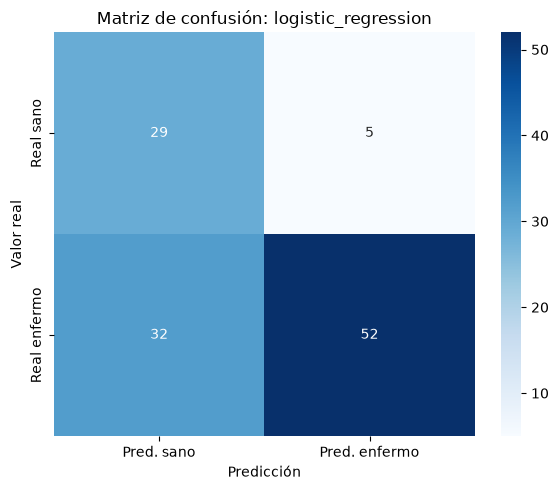

In [ ]:
def evaluate_model(estimator, features: pd.DataFrame, labels: pd.Series) -> pd.Series:
    predictions = estimator.predict(features)
    scores = positive_scores(estimator, features)
    true_negative, false_positive, _false_negative, _true_positive = confusion_matrix(
        labels, predictions, labels=[0, 1]
    ).ravel()
    return pd.Series(
        {
            "accuracy": accuracy_score(labels, predictions),
            "balanced_accuracy": balanced_accuracy_score(labels, predictions),
            "precision_disease": precision_score(labels, predictions, zero_division=0),
            "recall_disease": recall_score(labels, predictions, zero_division=0),
            "f1_disease": f1_score(labels, predictions, zero_division=0),
            "roc_auc": roc_auc_score(labels, scores),
            "average_precision": average_precision_score(labels, scores),
            "specificity": true_negative / (true_negative + false_positive),
        }
    )


train_metrics = evaluate_model(best_pipeline, X_train, y_train).rename("train")
test_metrics = evaluate_model(best_pipeline, X_test, y_test).rename("test")
final_metrics = pd.concat([train_metrics, test_metrics], axis=1).round(4)
display(final_metrics)

test_predictions = best_pipeline.predict(X_test)
print("Reporte de clasificación en test:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Sin enfermedad", "Enfermedad"],
        zero_division=0,
    )
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, test_predictions, labels=[0, 1]),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred. sano", "Pred. enfermo"],
    yticklabels=["Real sano", "Real enfermo"],
)
plt.title(f"Matriz de confusión: {selected_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

## 8. Underfitting, overfitting, learning curve y escalabilidad

,Train_size,Train_score_mean,Validation_score_mean,Fit_time_mean_seconds
0,75,0.7149,0.6884,0.1510
1,150,0.6899,0.6902,0.1697
2,225,0.6960,0.6959,0.1676
3,300,0.7118,0.6909,0.1690
4,376,0.7142,0.7076,0.1749


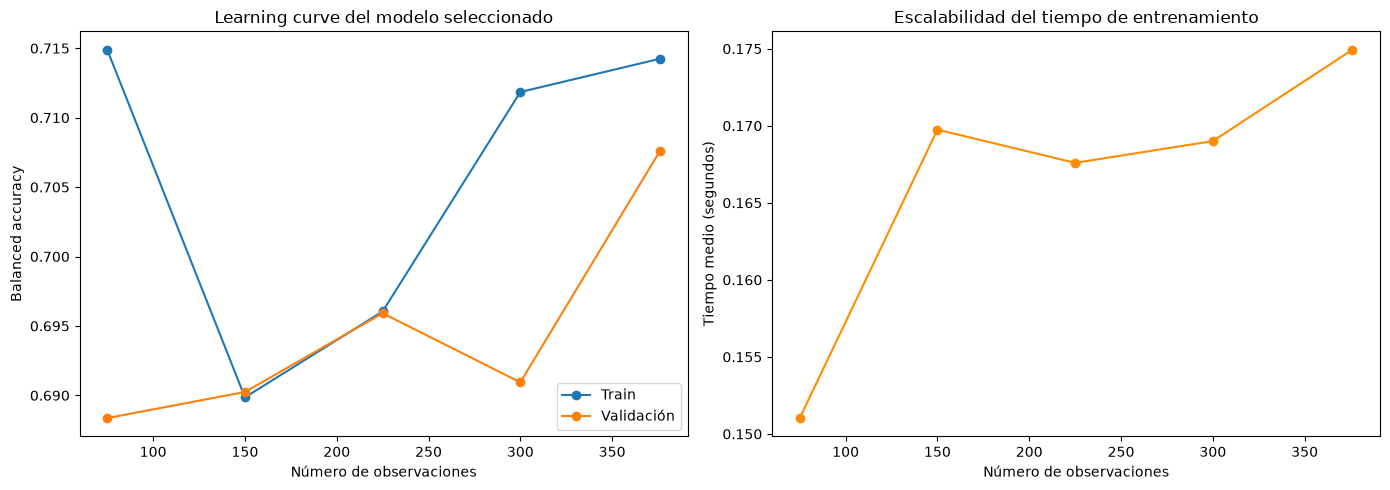

In [ ]:
train_sizes, train_scores, validation_scores, fit_times, _ = learning_curve(
    best_pipeline,
    X_train,
    y_train,
    cv=cv,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring="balanced_accuracy",
    return_times=True,
    n_jobs=-1,
)

learning_summary = pd.DataFrame(
    {
        "Train_size": train_sizes,
        "Train_score_mean": train_scores.mean(axis=1),
        "Validation_score_mean": validation_scores.mean(axis=1),
        "Fit_time_mean_seconds": fit_times.mean(axis=1),
    }
).round(4)
display(learning_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
axes[0].plot(train_sizes, validation_scores.mean(axis=1), marker="o", label="Validación")
axes[0].set_title("Learning curve del modelo seleccionado")
axes[0].set_xlabel("Número de observaciones")
axes[0].set_ylabel("Balanced accuracy")
axes[0].legend()

axes[1].plot(train_sizes, fit_times.mean(axis=1), marker="o", color="darkorange")
axes[1].set_title("Escalabilidad del tiempo de entrenamiento")
axes[1].set_xlabel("Número de observaciones")
axes[1].set_ylabel("Tiempo medio (segundos)")

plt.tight_layout()
plt.show()

## 9. Almacenamiento para el futuro despliegue

Se guarda el pipeline completo, no solo el estimador. Esto permite que Streamlit reciba las columnas clínicas originales y aplique automáticamente las mismas características derivadas, imputaciones, transformaciones y encoding usados durante el entrenamiento.

In [ ]:
MODEL_PATH = PROJECT_ROOT / "models" / "modelo_final.joblib"
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

model_artifact = {
    "pipeline": best_pipeline,
    "model_name": selected_model_name,
    "best_params": final_search.best_params_,
    "target_mapping": TARGET_MAPPING,
    "selection_metric": "balanced_accuracy",
    "test_metrics": test_metrics.to_dict(),
}
dump(model_artifact, MODEL_PATH)
print(f"Pipeline guardado en: {MODEL_PATH}")

Pipeline guardado en: C:\Users\dova1\Pacientes-problemas-higado-proyecto-data-Science\models\modelo_final.joblib


## 10. Conclusiones y recomendaciones

### Conclusiones Técnicas
* **Superación del Baseline:** El modelo final seleccionado (Regresión Logística) supera claramente al `DummyClassifier` base. El salto de un `balanced_accuracy` de 0.50 a 0.73 demuestra que el modelo extrajo patrones predictivos válidos más allá de la clase mayoritaria.
* **Evaluación Estadística:** Las pruebas estadísticas (T-pareada y Wilcoxon) no evidenciaron una superioridad significativa entre los mejores modelos, debido al tamaño reducido de la muestra de evaluación (5 folds). La selección del mejor modelo se justificó empíricamente mediante el promedio superior de validación.
* **Análisis de Métricas:** La métrica de *accuracy* es insuficiente frente al desbalance de los datos. Al evaluar el detalle, el modelo final logró una excelente precisión (**91.2%**) y especificidad (**85.2%**), pero un *recall* deficiente para la clase minoritaria (**61.9%**). 
* **Diagnóstico de Aprendizaje:** Las curvas de aprendizaje demuestran que no existe un problema grave de *overfitting* (brecha mínima entre validación y prueba). Sin embargo, el bajo *recall* sugiere un leve *underfitting* respecto a la capacidad de identificar casos positivos complejos.

### Recomendaciones y Próximos Pasos
* **Optimización Clínica (Recall):** En un contexto de diagnóstico de enfermedades, fallar un 40% de los casos positivos (falsos negativos) representa un riesgo alto. Se recomienda fuertemente realizar un ajuste del umbral de decisión (*threshold tuning*) para incrementar el *recall*, incluso si esto sacrifica algunos puntos de precisión.
* **Iteración del Modelado:** Para mejorar el poder predictivo general, es recomendable regresar a la fase de *feature engineering* para crear nuevas variables cruzadas, o explorar técnicas de aprendizaje sensible al costo.
* **Despliegue Técnico:** El almacenamiento del pipeline completo en `.joblib` junto con las clases modulares en `src/model/preprocessing.py` garantiza la reproducibilidad exacta de las transformaciones de datos originales para una futura integración en Streamlit.
* **Validación en Producción:** Las predicciones de este modelo son estrictamente analíticas y no constituyen un diagnóstico médico real. Antes de cualquier prueba en la vida real, el sistema requiere calibración de probabilidades, validación externa con un dataset independiente y revisión estricta por especialistas de dominio.